Found 14 galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4383', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']


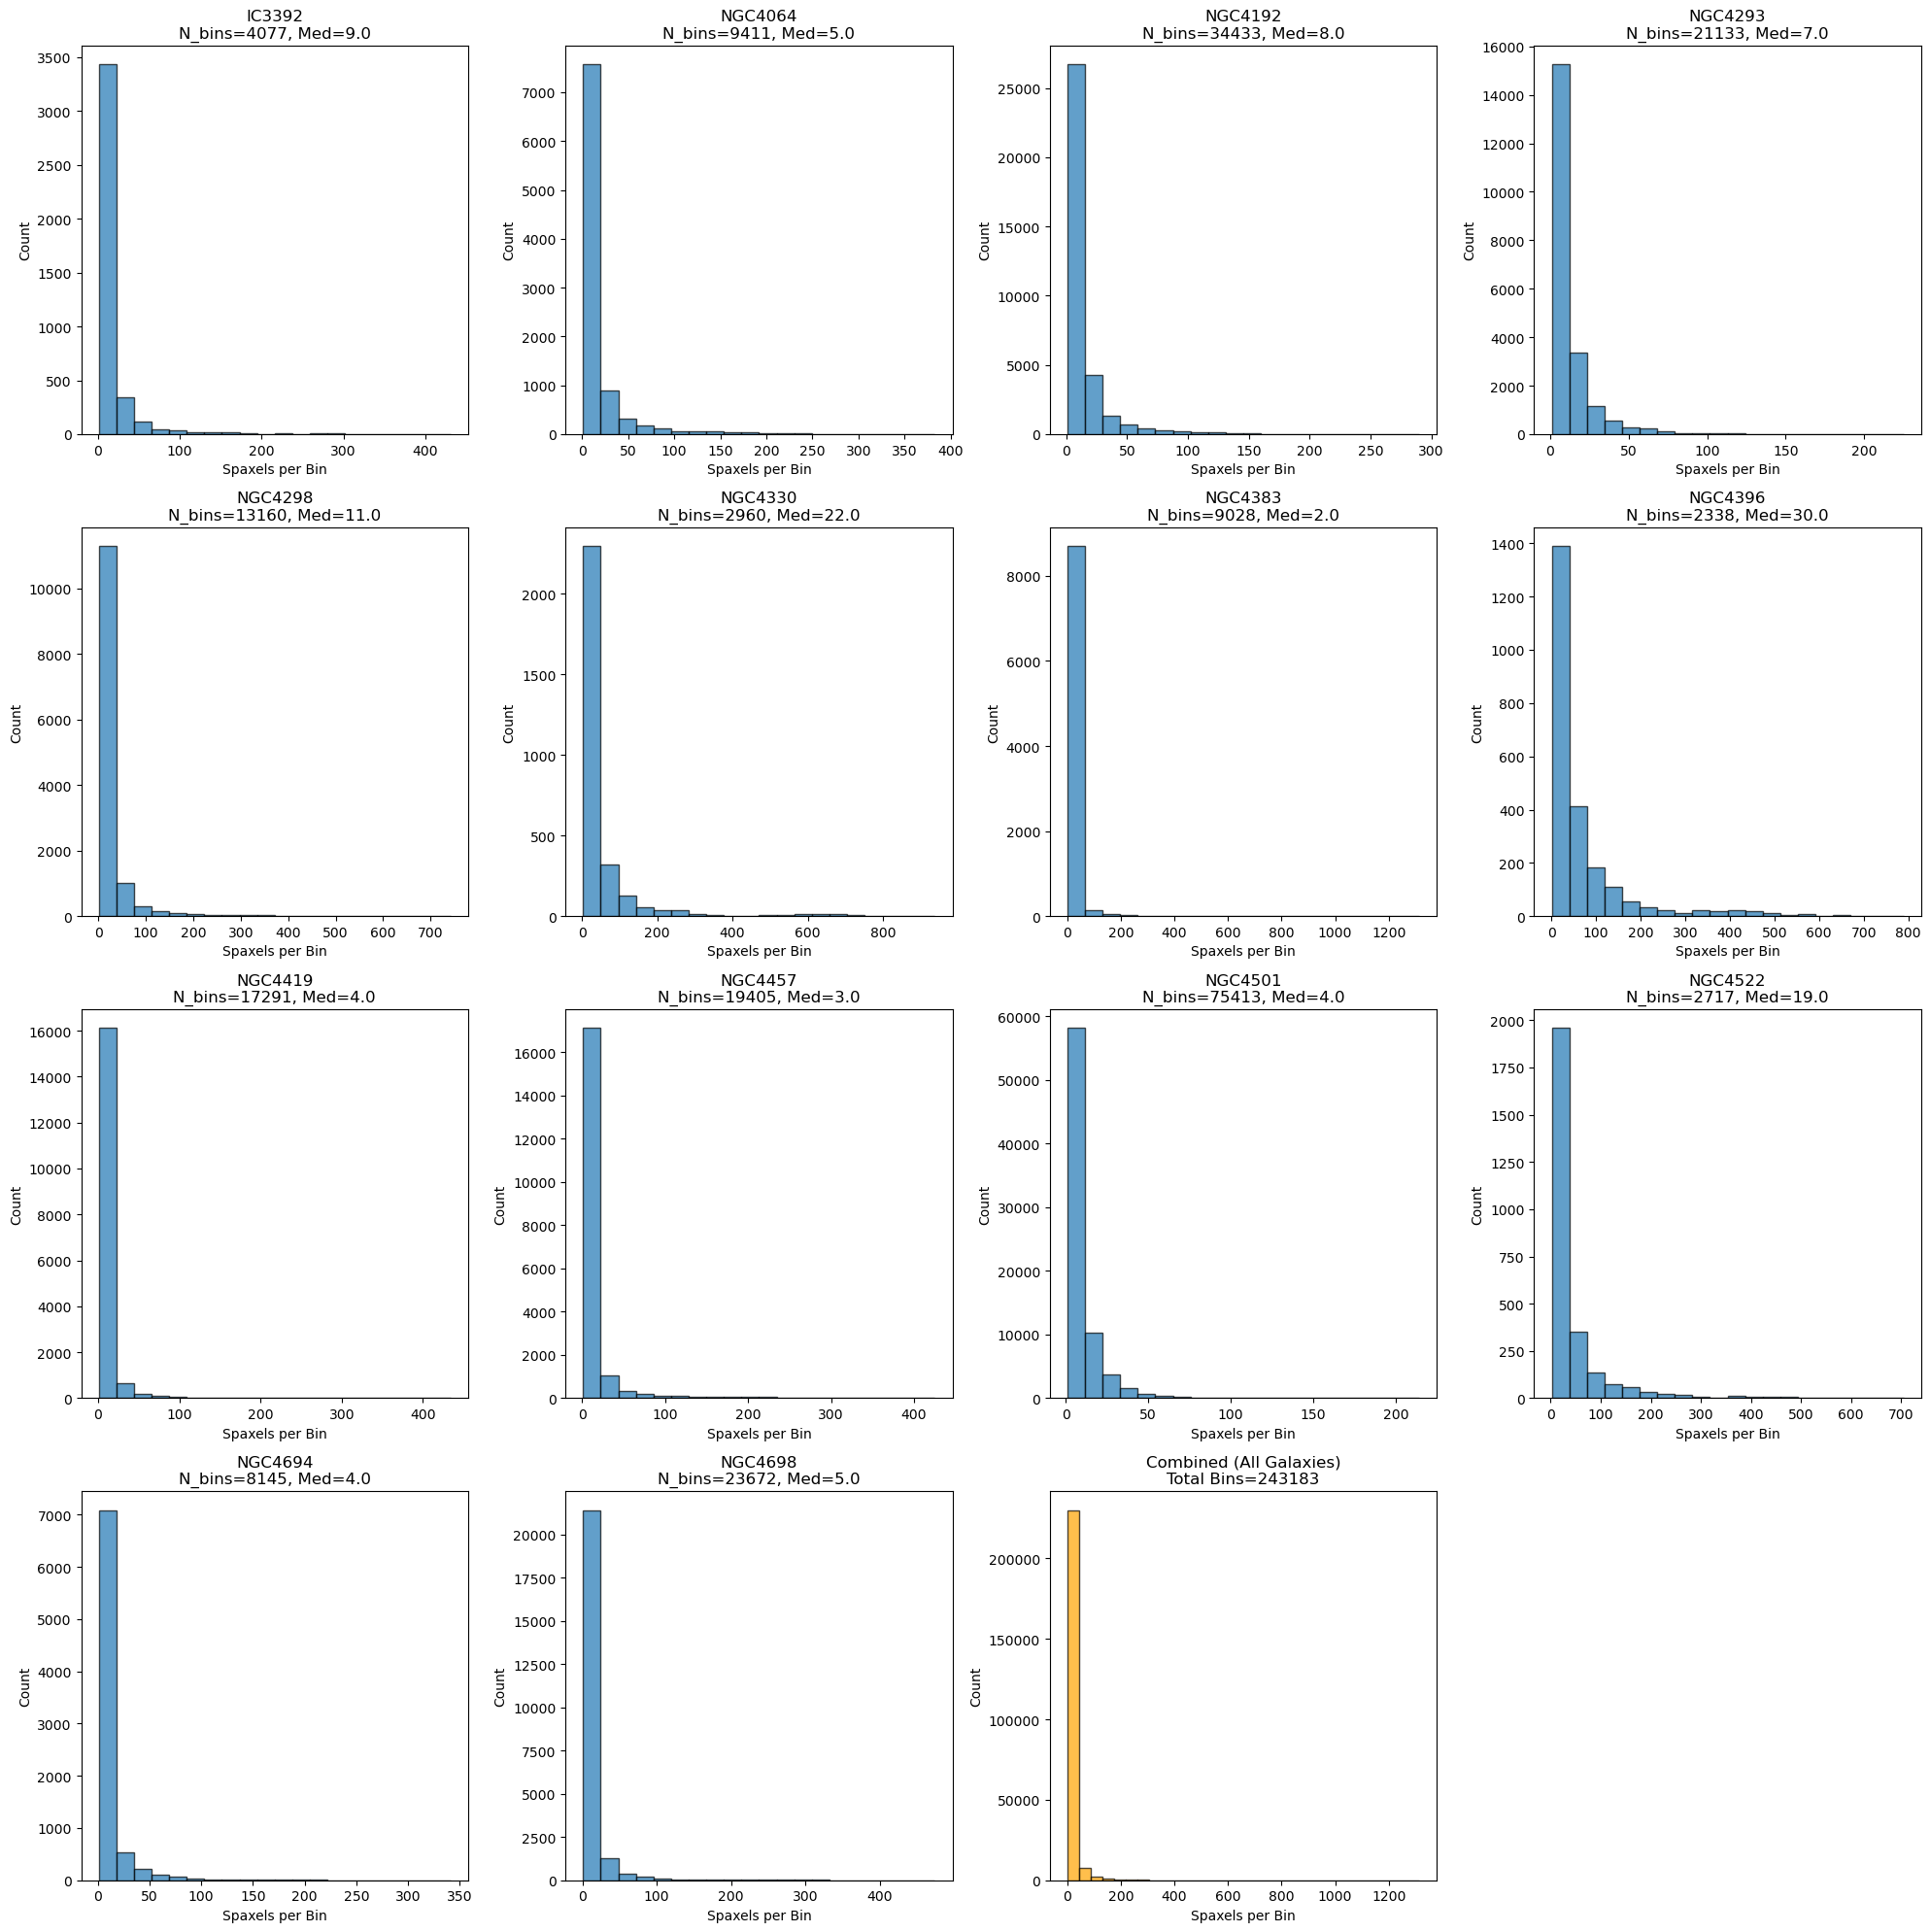


--- Statistics of Spaxels per Bin (finite BINID only) ---
Galaxy     | Mean     | Median   | Std      | Min   | Max   | N_bins | Top5                      | thr68  | thr95  | thr99.7
------------------------------------------------------------------------------------------------------------------------------------------------------
IC3392     | 17.95    | 9.00     | 34.89    | 1     | 431   | 4077   | 431,420,406,373,359       | 14     | 58     | 296    
NGC4064    | 16.74    | 5.00     | 33.23    | 1     | 383   | 9411   | 383,365,338,309,307       | 10     | 73     | 241    
NGC4192    | 14.21    | 8.00     | 21.12    | 1     | 290   | 34433  | 290,288,283,263,256       | 12     | 51     | 153    
NGC4293    | 11.86    | 7.00     | 14.95    | 1     | 225   | 21133  | 225,189,171,168,162       | 11     | 40     | 111    
NGC4298    | 26.60    | 11.00    | 56.96    | 1     | 742   | 13160  | 742,703,663,658,638       | 19     | 97     | 505    
NGC4330    | 53.17    | 22.00    | 100.7

In [1]:
# ------------------------------------------------------------------
# Analysis of spaxels per bin (finite BINID only)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
print(f"Found {len(galaxies)} galaxies: {galaxies}")

all_spaxel_counts = []
galaxy_stats = {}

# Create a grid of subplots
n_cols = 4
n_rows = int(np.ceil((len(galaxies) + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, gal in enumerate(galaxies):
    filename = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    try:
        with fits.open(filename) as h:
            # Check if 'BINID' HDU exists, otherwise try 'BIN'
            if 'BINID' in h:
                bin_map = h['BINID'].data
            elif 'BIN' in h:
                bin_map = h['BIN'].data
            else:
                print(f"Warning: 'BINID' or 'BIN' HDU not found in {filename}")
                continue

            # Keep only finite values (ignore NaN/Inf)
            finite_mask = np.isfinite(bin_map)
            valid_bins = bin_map[finite_mask]

            if valid_bins.size == 0:
                print(f"No finite bin values in {gal}")
                continue

            unique_bins, counts = np.unique(valid_bins, return_counts=True)

            # Aggregate all spaxel counts
            all_spaxel_counts.extend(counts)

            # Statistics for this galaxy
            mean_spaxels = np.mean(counts)
            median_spaxels = np.median(counts)
            std_spaxels = np.std(counts)
            min_spaxels = np.min(counts)
            max_spaxels = np.max(counts)
            
            # Top 5 largest spaxels-per-bin values
            sorted_counts = np.sort(counts)[::-1]
            top5 = sorted_counts[:5]
            
            # Completeness levels (1-spaxel per bin minimum by construction)
            # Find maximum spaxels-per-bin threshold such that
            # 68%, 95%, 99.7% of bins have counts <= threshold
            sorted_counts_asc = np.sort(counts)
            n_bins = len(sorted_counts_asc)
            def completeness_threshold(frac):
                idx = int(np.ceil(frac * n_bins)) - 1
                idx = np.clip(idx, 0, n_bins - 1)
                return sorted_counts_asc[idx]
            thr_68 = completeness_threshold(0.68)
            thr_95 = completeness_threshold(0.95)
            thr_997 = completeness_threshold(0.997)

            galaxy_stats[gal] = {
                'mean': mean_spaxels,
                'median': median_spaxels,
                'std': std_spaxels,
                'min': min_spaxels,
                'max': max_spaxels,
                'num_bins': n_bins,
                'top5': top5,
                'thr_68': thr_68,
                'thr_95': thr_95,
                'thr_997': thr_997
            }

            # Plot per-galaxy histogram
            ax = axes[i]
            ax.hist(counts, bins=20, edgecolor='black', alpha=0.7)
            ax.set_title(f'{gal}\nN_bins={n_bins}, Med={median_spaxels:.1f}')
            ax.set_xlabel('Spaxels per Bin')
            ax.set_ylabel('Count')

    except Exception as e:
        print(f"Error processing {gal}: {e}")

# Combined plot of all finite spaxel counts
if len(galaxies) < len(axes):
    ax_combined = axes[len(galaxies)]
    if all_spaxel_counts:
        ax_combined.hist(all_spaxel_counts, bins=30, color='orange', edgecolor='black', alpha=0.7)
        ax_combined.set_title(f'Combined (All Galaxies)\nTotal Bins={len(all_spaxel_counts)}')
        ax_combined.set_xlabel('Spaxels per Bin')
        ax_combined.set_ylabel('Count')
    else:
        ax_combined.set_axis_off()

# Hide unused subplots
for j in range(len(galaxies) + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Print Statistics
print("\n--- Statistics of Spaxels per Bin (finite BINID only) ---")
print(f"{'Galaxy':<10} | {'Mean':<8} | {'Median':<8} | {'Std':<8} | {'Min':<5} | {'Max':<5} | {'N_bins':<6} | {'Top5':<25} | {'thr68':<6} | {'thr95':<6} | {'thr99.7':<7}")
print("-" * 150)
for gal in galaxies:
    if gal in galaxy_stats:
        s = galaxy_stats[gal]
        top5_str = ','.join([str(int(v)) for v in s['top5']])
        print(
            f"{gal:<10} | {s['mean']:<8.2f} | {s['median']:<8.2f} | {s['std']:<8.2f} | "
            f"{s['min']:<5d} | {s['max']:<5d} | {s['num_bins']:<6d} | {top5_str:<25} | "
            f"{int(s['thr_68']):<6d} | {int(s['thr_95']):<6d} | {int(s['thr_997']):<7d}"
)

if all_spaxel_counts:
    all_mean = np.mean(all_spaxel_counts)
    all_median = np.median(all_spaxel_counts)
    all_std = np.std(all_spaxel_counts)
    all_min = np.min(all_spaxel_counts)
    all_max = np.max(all_spaxel_counts)

    # Combined Top5 and completeness thresholds
    all_counts_array = np.array(all_spaxel_counts)
    sorted_all_desc = np.sort(all_counts_array)[::-1]
    combined_top5 = sorted_all_desc[:5]
    sorted_all_asc = np.sort(all_counts_array)
    n_all = len(sorted_all_asc)
    def combined_thr(frac):
        idx = int(np.ceil(frac * n_all)) - 1
        idx = np.clip(idx, 0, n_all - 1)
        return sorted_all_asc[idx]
    all_thr_68 = combined_thr(0.68)
    all_thr_95 = combined_thr(0.95)
    all_thr_997 = combined_thr(0.997)
    combined_top5_str = ','.join([str(int(v)) for v in combined_top5])

    print("-" * 150)
    print(
        f"{'Combined':<10} | {all_mean:<8.2f} | {all_median:<8.2f} | {all_std:<8.2f} | "
        f"{all_min:<5d} | {all_max:<5d} | {n_all:<6d} | {combined_top5_str:<25} | "
        f"{int(all_thr_68):<6d} | {int(all_thr_95):<6d} | {int(all_thr_997):<7d}"
)

In [2]:
# Calculate physical scale at 16.5 Mpc distance
distance_Mpc = 16.5  # Mpc
angular_scale_arcsec = 0.2  # arcsec

# Convert distance to parsecs
distance_pc = distance_Mpc * 1e6  # pc

# Convert arcsec to radians
angular_scale_rad = angular_scale_arcsec / 206265  # 1 radian = 206265 arcsec

# Calculate physical scale in pc
physical_scale_pc = distance_pc * angular_scale_rad

print(f"Angular scale: {angular_scale_arcsec} arcsec")
print(f"Distance: {distance_Mpc} Mpc")
print(f"Physical scale: {physical_scale_pc:.2f} pc")

Angular scale: 0.2 arcsec
Distance: 16.5 Mpc
Physical scale: 16.00 pc


Found 14 galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4383', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']


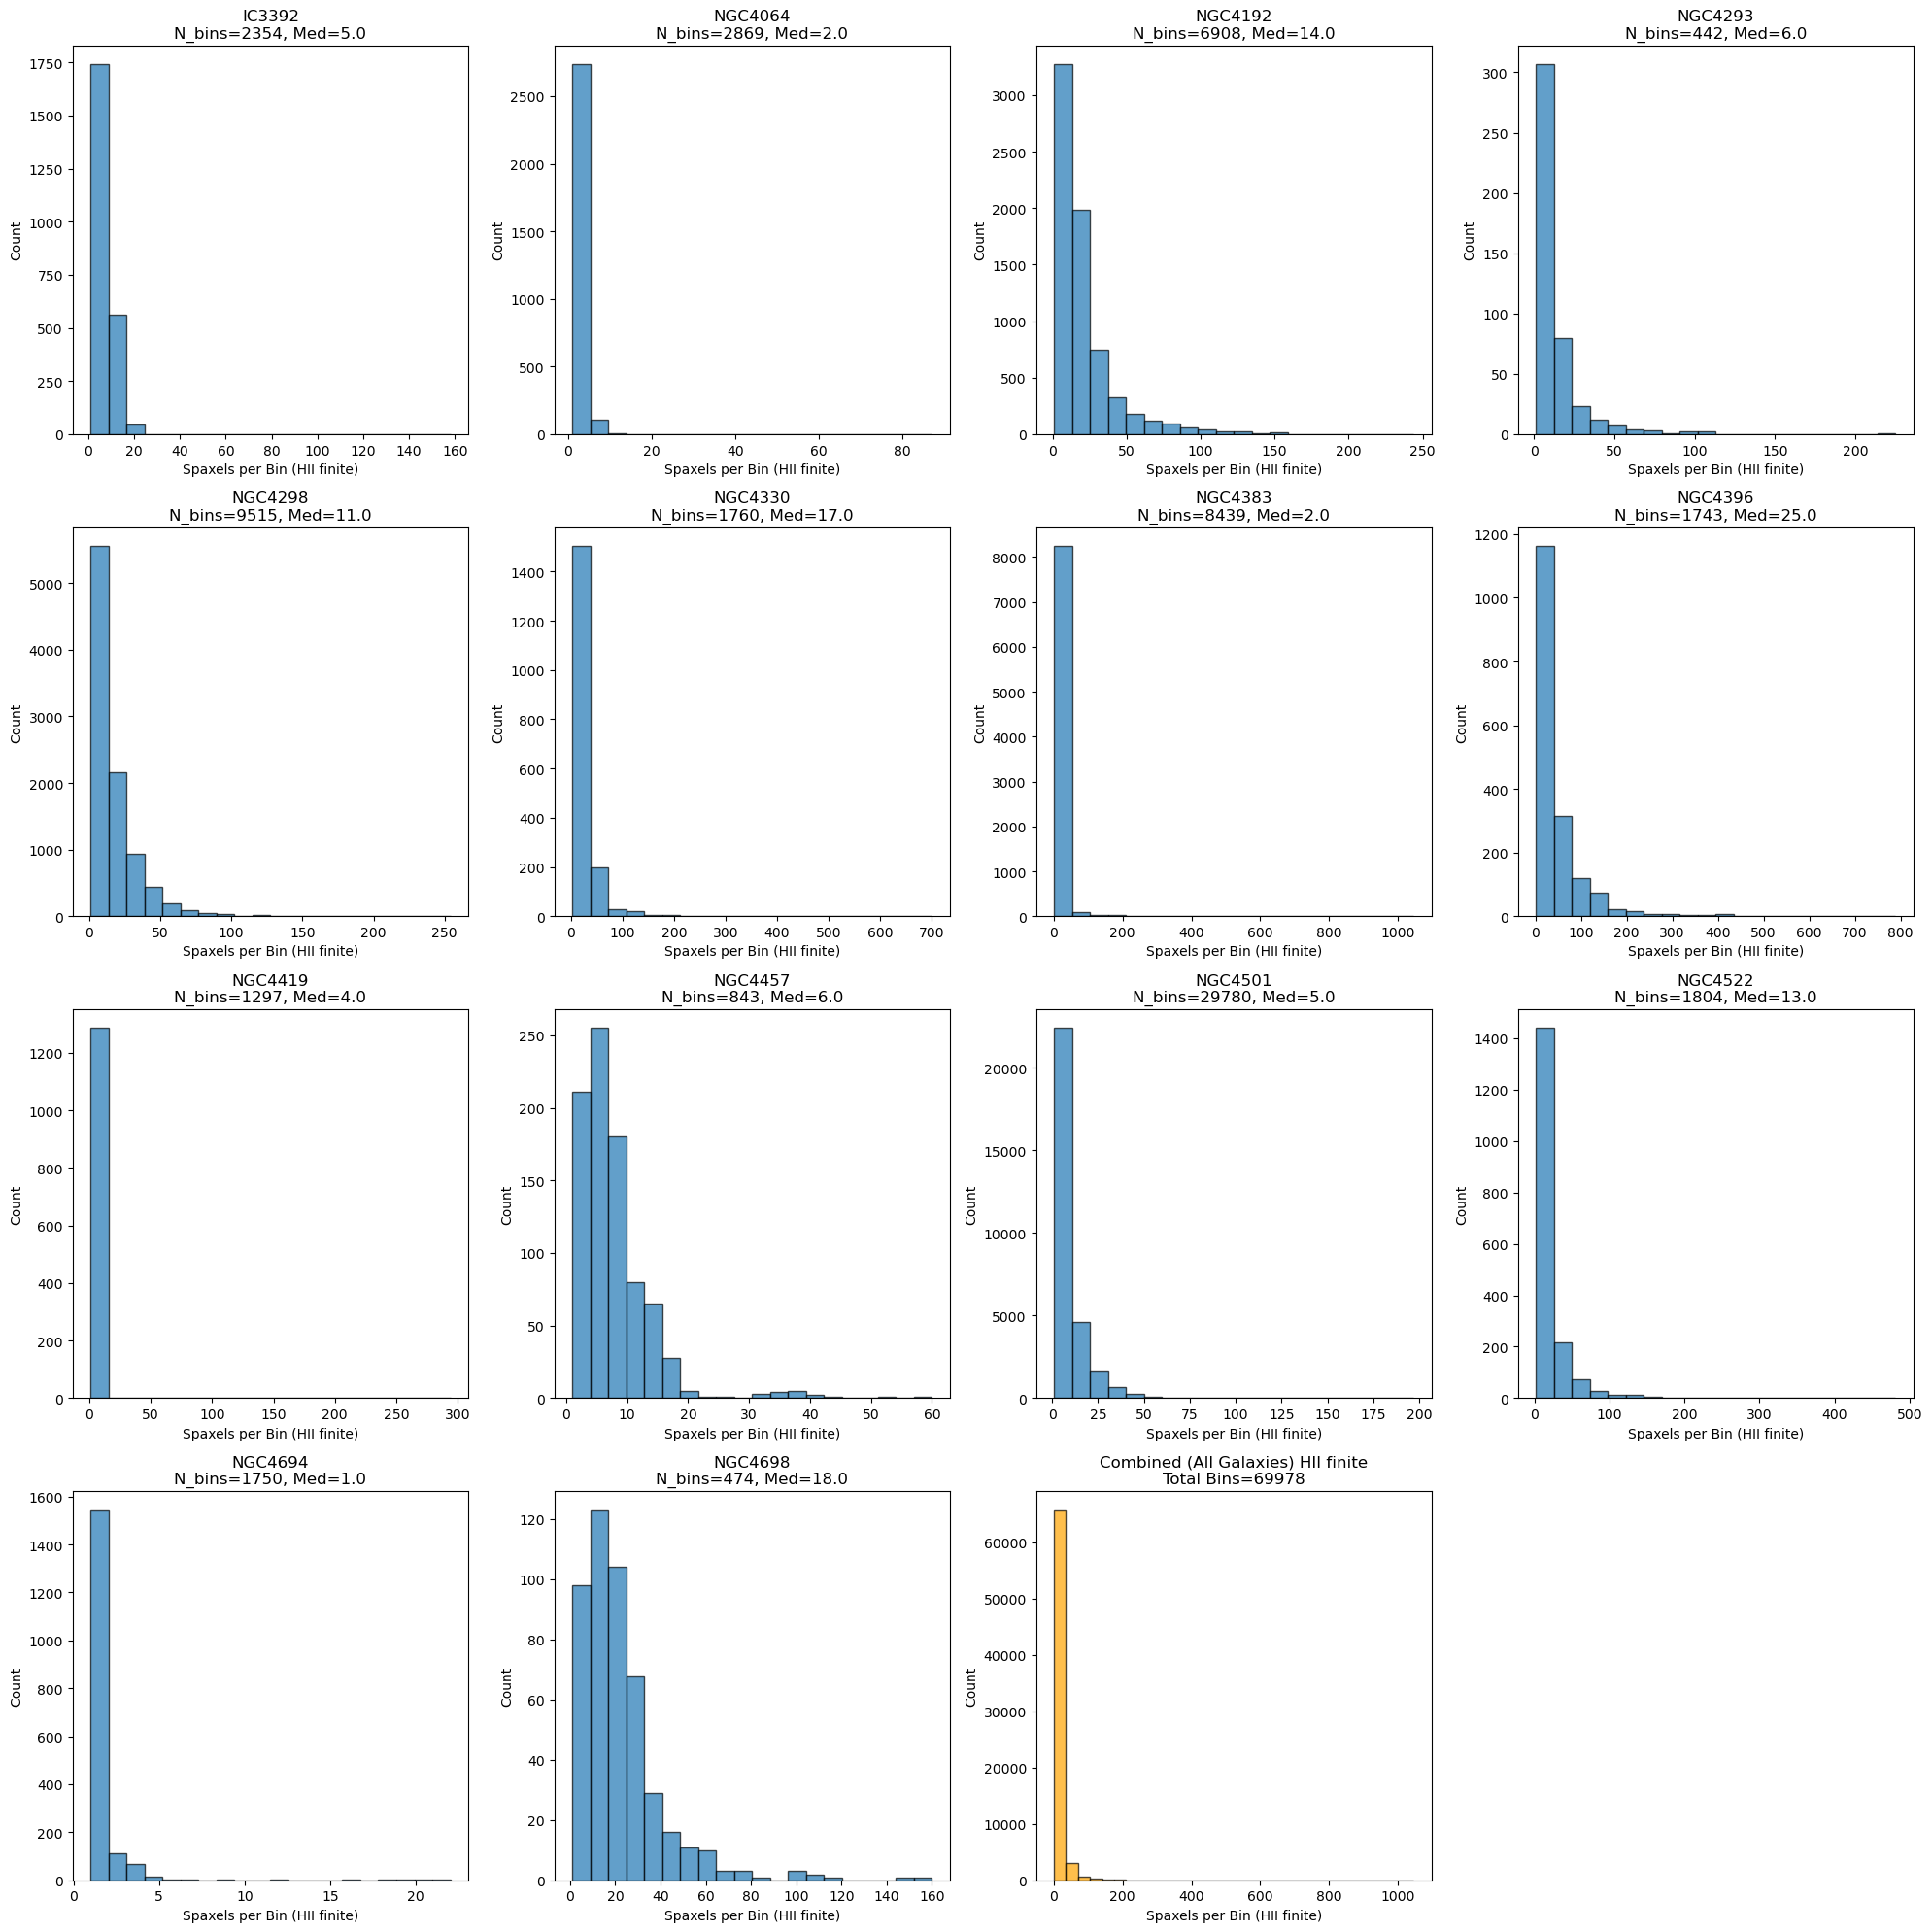


--- Statistics of Spaxels per Bin (finite BINID & finite HII ΣSFR) ---
Galaxy     | Mean     | Median   | Std      | Min   | Max   | N_bins | Top5                      | thr68  | thr95  | thr99.7
------------------------------------------------------------------------------------------------------------------------------------------------------
IC3392     | 6.32     | 5.00     | 5.87     | 1     | 158   | 2354   | 158,123,78,51,23          | 7      | 14     | 21     
NGC4064    | 2.46     | 2.00     | 3.31     | 1     | 87    | 2869   | 87,58,56,53,47            | 2      | 5      | 31     
NGC4192    | 21.13    | 14.00    | 22.27    | 1     | 244   | 6908   | 244,234,201,193,186       | 21     | 66     | 149    
NGC4293    | 12.93    | 6.00     | 18.32    | 1     | 225   | 442    | 225,111,105,97,96         | 12     | 44     | 111    
NGC4298    | 16.43    | 11.00    | 18.37    | 1     | 254   | 9515   | 254,242,231,225,210       | 17     | 49     | 125    
NGC4330    | 24.43    | 17.

In [3]:
# ------------------------------------------------------------------
# Analysis of spaxels per bin (finite BINID & finite HII ΣSFR)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# Get all galaxies (reuse same pattern)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
print(f"Found {len(galaxies)} galaxies: {galaxies}")

all_spaxel_counts = []
galaxy_stats = {}

# Create a grid of subplots
n_cols = 4
n_rows = int(np.ceil((len(galaxies) + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, gal in enumerate(galaxies):
    bin_filename = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_filename = f'{gal}_gas_BIN_maps_extended.fits'
    try:
        with fits.open(bin_filename) as h_bin, fits.open(gas_filename) as h_gas:
            # BIN map
            if 'BINID' in h_bin:
                bin_map = h_bin['BINID'].data
            elif 'BIN' in h_bin:
                bin_map = h_bin['BIN'].data
            else:
                print(f"Warning: 'BINID' or 'BIN' HDU not found in {bin_filename}")
                continue

            # HII regions ΣSFR map
            if 'LOGSFR_SURFACE_DENSITY_HII' not in h_gas:
                print(f"Warning: 'LOGSFR_SURFACE_DENSITY_HII' HDU not found in {gas_filename}")
                continue
            sigSFR_HII = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data

            # Ensure shapes match
            if bin_map.shape != sigSFR_HII.shape:
                print(f"Shape mismatch for {gal}: BIN map {bin_map.shape}, HII map {sigSFR_HII.shape}")
                continue

            # Mask: finite BINID and finite HII ΣSFR
            mask = np.isfinite(bin_map) & np.isfinite(sigSFR_HII)
            valid_bins = bin_map[mask]

            if valid_bins.size == 0:
                print(f"No finite BINID + HII ΣSFR spaxels in {gal}")
                continue

            unique_bins, counts = np.unique(valid_bins, return_counts=True)

            # Aggregate all spaxel counts
            all_spaxel_counts.extend(counts)

            # Statistics for this galaxy
            mean_spaxels = np.mean(counts)
            median_spaxels = np.median(counts)
            std_spaxels = np.std(counts)
            min_spaxels = np.min(counts)
            max_spaxels = np.max(counts)

            # Top 5 largest spaxels-per-bin values
            sorted_counts = np.sort(counts)[::-1]
            top5 = sorted_counts[:5]

            # Completeness thresholds in terms of max spaxels-per-bin
            sorted_counts_asc = np.sort(counts)
            n_bins = len(sorted_counts_asc)
            def completeness_threshold(frac):
                idx = int(np.ceil(frac * n_bins)) - 1
                idx = np.clip(idx, 0, n_bins - 1)
                return sorted_counts_asc[idx]
            thr_68 = completeness_threshold(0.68)
            thr_95 = completeness_threshold(0.95)
            thr_997 = completeness_threshold(0.997)

            galaxy_stats[gal] = {
                'mean': mean_spaxels,
                'median': median_spaxels,
                'std': std_spaxels,
                'min': min_spaxels,
                'max': max_spaxels,
                'num_bins': n_bins,
                'top5': top5,
                'thr_68': thr_68,
                'thr_95': thr_95,
                'thr_997': thr_997
            }

            # Plot per-galaxy histogram
            ax = axes[i]
            ax.hist(counts, bins=20, edgecolor='black', alpha=0.7)
            ax.set_title(f'{gal}\nN_bins={n_bins}, Med={median_spaxels:.1f}')
            ax.set_xlabel('Spaxels per Bin (HII finite)')
            ax.set_ylabel('Count')

    except Exception as e:
        print(f"Error processing {gal}: {e}")

# Combined plot of all finite spaxel counts (HII finite)
if len(galaxies) < len(axes):
    ax_combined = axes[len(galaxies)]
    if all_spaxel_counts:
        ax_combined.hist(all_spaxel_counts, bins=30, color='orange', edgecolor='black', alpha=0.7)
        ax_combined.set_title(f'Combined (All Galaxies) HII finite\nTotal Bins={len(all_spaxel_counts)}')
        ax_combined.set_xlabel('Spaxels per Bin (HII finite)')
        ax_combined.set_ylabel('Count')
    else:
        ax_combined.set_axis_off()

# Hide unused subplots
for j in range(len(galaxies) + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Print Statistics
print("\n--- Statistics of Spaxels per Bin (finite BINID & finite HII ΣSFR) ---")
print(f"{'Galaxy':<10} | {'Mean':<8} | {'Median':<8} | {'Std':<8} | {'Min':<5} | {'Max':<5} | {'N_bins':<6} | {'Top5':<25} | {'thr68':<6} | {'thr95':<6} | {'thr99.7':<7}")
print("-" * 150)
for gal in galaxies:
    if gal in galaxy_stats:
        s = galaxy_stats[gal]
        top5_str = ','.join([str(int(v)) for v in s['top5']])
        print(
            f"{gal:<10} | {s['mean']:<8.2f} | {s['median']:<8.2f} | {s['std']:<8.2f} | "
            f"{s['min']:<5d} | {s['max']:<5d} | {s['num_bins']:<6d} | {top5_str:<25} | "
            f"{int(s['thr_68']):<6d} | {int(s['thr_95']):<6d} | {int(s['thr_997']):<7d}"
)

if all_spaxel_counts:
    all_mean = np.mean(all_spaxel_counts)
    all_median = np.median(all_spaxel_counts)
    all_std = np.std(all_spaxel_counts)
    all_min = np.min(all_spaxel_counts)
    all_max = np.max(all_spaxel_counts)

    # Combined Top5 and completeness thresholds for HII-finite case
    all_counts_array = np.array(all_spaxel_counts)
    sorted_all_desc = np.sort(all_counts_array)[::-1]
    combined_top5 = sorted_all_desc[:5]
    sorted_all_asc = np.sort(all_counts_array)
    n_all = len(sorted_all_asc)
    def combined_thr(frac):
        idx = int(np.ceil(frac * n_all)) - 1
        idx = np.clip(idx, 0, n_all - 1)
        return sorted_all_asc[idx]
    all_thr_68 = combined_thr(0.68)
    all_thr_95 = combined_thr(0.95)
    all_thr_997 = combined_thr(0.997)
    combined_top5_str = ','.join([str(int(v)) for v in combined_top5])

    print("-" * 150)
    print(
        f"{'Combined':<10} | {all_mean:<8.2f} | {all_median:<8.2f} | {all_std:<8.2f} | "
        f"{all_min:<5d} | {all_max:<5d} | {n_all:<6d} | {combined_top5_str:<25} | "
        f"{int(all_thr_68):<6d} | {int(all_thr_95):<6d} | {int(all_thr_997):<7d}"
)